### [Simulate Card Shuffling with Python](https://medium.com/data-science-collective/c953c5915f25)

> *When is a deck fully random?*

#### Shuffling with a GSR Markov Chain

The **Gilbert–Shannon–Reeds (GSR)** model describes a probability distribution over all possible riffle‑shuffle permutations. A *riffle shuffle* is the familiar motion of splitting a deck into two packets and rapidly interleaving them.

Estimate the **Total Variation (TV) Distance** between the top‑card distribution and a perfectly uniform one. This requires running thousands of simulated shuffles.

*Total Variation Distance* measures how far apart two probability distributions are. In the context of card shuffling, it tells us how different our deck’s distribution is from an ideal uniform distribution produced by a perfectly random deck.



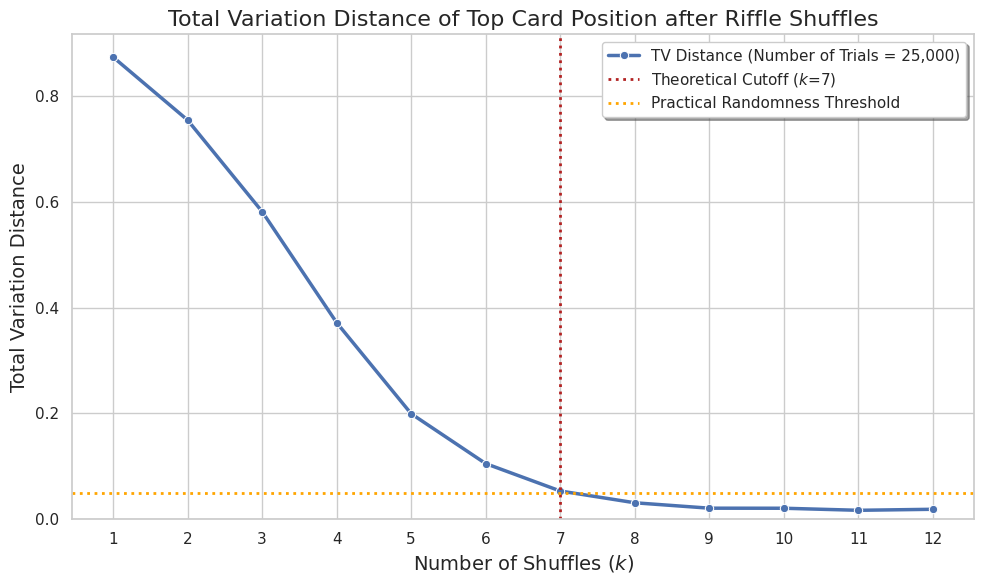

In [1]:
import os, sys
IN_COLAB = "google.colab" in sys.modules or "google.colab" in str(get_ipython())

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
np.seterr(divide='ignore', invalid='ignore')

import warnings
warnings.filterwarnings("ignore")

def inverse_gsr_shuffle(deck: np.ndarray,
                        rng: np.random.Generator) -> np.ndarray:
    """
    Perform one inverse GSR (Gilbert–Shannon–Reeds) riffle shuffle.

    Each card is assigned a random bit (0/1) and the deck is stably sorted
    by those bits. This is mathematically equivalent to one riffle shuffle.
    """
    bits = rng.integers(0, 2, size=deck.size, dtype=np.int8)
    order = np.argsort(bits, kind="stable")
    return deck[order]


def calculate_tv_distance(num_trials: int, k_shuffles: int,
                          rng: np.random.Generator) -> float:
    """
    Estimate total variation distance of the top card distribution from uniform
    after k_shuffles riffle shuffles.
    """
    counts = np.zeros(52, dtype=np.int64)

    for _ in range(num_trials):
        deck = np.arange(52)

        for _ in range(k_shuffles):
            deck = inverse_gsr_shuffle(deck, rng)

        counts[deck[0]] += 1

    empirical = counts / num_trials
    uniform = 1 / 52
    tv_distance = 0.5 * np.abs(empirical - uniform).sum()

    return tv_distance


def main():
    # --- Parameters ---
    num_trials = 25_000
    shuffles_range = range(1, 13)

    rng = np.random.default_rng()

    # --- Data collection ---
    tv_values = [calculate_tv_distance(num_trials, k, rng)
                 for k in shuffles_range]

    # --- Plotting ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        x=list(shuffles_range), y=tv_values, marker="o", lw=2.5,
        label=f"TV Distance (Number of Trials ={num_trials: ,})"
    )

    plt.ylim(0, None)

    # Add reference lines:
    plt.axvline(x=7, c="firebrick", ls=":", lw=2,
                label="Theoretical Cutoff ($k$=7)")
    plt.axhline(y=0.05, c="orange", ls=":", lw=2,
        label="Practical Randomness Threshold")

    plt.title(
        "Total Variation Distance of Top Card Position after Riffle Shuffles",
        fontsize=16
    )
    plt.xlabel("Number of Shuffles ($k$)", fontsize=14)
    plt.ylabel("Total Variation Distance", fontsize=14)
    plt.xticks(list(shuffles_range))
    plt.legend(framealpha=1, shadow=True)
    plt.tight_layout()

    if not IN_COLAB:
      plt.savefig('shuffle_plot.png', dpi=600)
    plt.show()


if __name__ == "__main__":
    main()